In [1]:
!pip install -q git+https://github.com/probml/dynamax.git

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.9/55.9 kB 3.3 MB/s eta 0:00:00


2025-11-03 04:04:14.468711: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1762142654.645801      37 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1762142654.709077      37 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


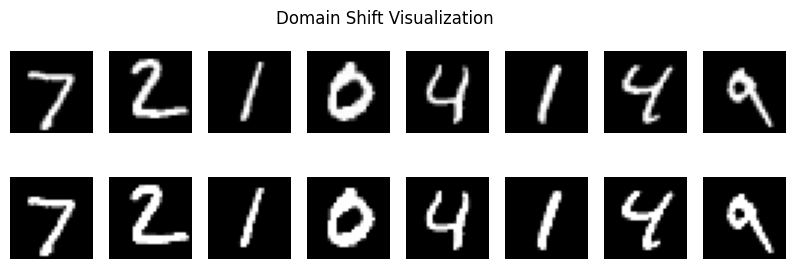

In [2]:
# =====================================
# 1. Setup and Data Preparation
# =====================================
import jax, jax.numpy as jnp
import optax, numpy as np, matplotlib.pyplot as plt, time
from flax import nnx
from tensorflow.keras.datasets import mnist
import copy

(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train, X_test = X_train / 255.0, X_test / 255.0
X_train = X_train.reshape(-1, 28, 28)
X_test  = X_test.reshape(-1, 28, 28)

# contrast and brightness shift
X_test_shifted = np.clip(((X_test - 0.5) * 1.8 + 0.5) + 0.4, 0, 1)
y_test_shifted = y_test

fig, axes = plt.subplots(2, 8, figsize=(10, 3))
for i in range(8):
    axes[0, i].imshow(X_test[i], cmap="gray");       axes[0, i].axis("off")
    axes[1, i].imshow(X_test_shifted[i], cmap="gray");axes[1, i].axis("off")
axes[0, 0].set_ylabel("Original", rotation=0, labelpad=40)
axes[1, 0].set_ylabel("Shifted", rotation=0, labelpad=40)
plt.suptitle("Domain Shift Visualization")
plt.show()

In [3]:
# =====================================
# 2. Define Simple RNN Model (NNX)
# =====================================
class SimpleRNN(nnx.Module):
    def __init__(self, input_dim, hidden_dim, num_classes, *, rngs: nnx.Rngs):
        # input-to-hidden and hidden-to-hidden transformations
        self.hidden_size = hidden_dim
        self.Wxh = nnx.Linear(input_dim, hidden_dim, rngs=rngs)
        self.Whh = nnx.Linear(hidden_dim, hidden_dim, rngs=rngs)
        self.fc  = nnx.Linear(hidden_dim, num_classes, rngs=rngs)

    def __call__(self, x, h):
        # x: (batch, seq, feat)
        for t in range(x.shape[1]):
            h = jnp.tanh(self.Wxh(x[:, t, :]) + self.Whh(h))
        return self.fc(h)


In [4]:
# =====================================
# 3. Loss, Accuracy, and Utility
# =====================================
def cross_entropy(logits, labels):
    y = jax.nn.one_hot(labels, 10)
    return -jnp.mean(jnp.sum(y * jax.nn.log_softmax(logits), axis=-1))

def accuracy(logits, labels):
    return jnp.mean(jnp.argmax(logits, -1) == labels)

def eval_batch(model, x, y):
    h0 = jnp.zeros((x.shape[0], model.hidden_size))
    logits = model(x, h0)
    return cross_entropy(logits, y), accuracy(logits, y)


In [5]:

# =====================================
# 4. Baseline Training
# =====================================
rngs = nnx.Rngs(0)
model = SimpleRNN(28, 128, 10, rngs=rngs)
#model = SimpleRNN(28, 10, 10, rngs=rngs)
optimizer = nnx.Optimizer(model, optax.adam(2e-3))

epochs = 30
batch_size = 1024
train_losses, test_accs = [], []

print("\nTraining baseline RNN...")
for ep in range(epochs):
    # random mini-batch sampling
    idx = np.random.choice(len(X_train), batch_size, replace=False)
    Xb, yb = X_train[idx], y_train[idx]

    def loss_fn(model):
        h0 = jnp.zeros((Xb.shape[0], model.hidden_size))
        logits = model(Xb, h0)
        loss = cross_entropy(logits, yb)
        return loss, logits

    (loss_value, _), grads = nnx.value_and_grad(loss_fn, has_aux=True)(model)
    optimizer.update(grads)

    # evaluate every 2 epochs
    if (ep + 1) % 2 == 0 or ep == 0:
        l, a = eval_batch(model, X_test, y_test)
        train_losses.append(float(loss_value))
        test_accs.append(float(a))
        print(f"Epoch {ep+1}/{epochs}: train_loss={float(loss_value):.4f} test_acc={float(a):.4f}")

baseline_model = copy.deepcopy(model)
l_shift, a_shift = eval_batch(model, X_test_shifted, y_test_shifted)
print(f"Baseline accuracy (orig): {test_accs[-1]:.4f}")
print(f"Baseline accuracy (shifted): {a_shift:.4f}")


INFO:2025-11-03 04:04:25,753:jax._src.xla_bridge:924: Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
INFO:2025-11-03 04:04:25,764:jax._src.xla_bridge:924: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory



Training baseline RNN...
Epoch 1/30: train_loss=2.3197 test_acc=0.2359
Epoch 2/30: train_loss=2.1695 test_acc=0.3254
Epoch 4/30: train_loss=1.9510 test_acc=0.3894
Epoch 6/30: train_loss=1.7660 test_acc=0.4557
Epoch 8/30: train_loss=1.6094 test_acc=0.5408
Epoch 10/30: train_loss=1.4471 test_acc=0.5537
Epoch 12/30: train_loss=1.3186 test_acc=0.5900
Epoch 14/30: train_loss=1.1411 test_acc=0.6176
Epoch 16/30: train_loss=1.1546 test_acc=0.6278
Epoch 18/30: train_loss=1.0907 test_acc=0.6567
Epoch 20/30: train_loss=0.9290 test_acc=0.6764
Epoch 22/30: train_loss=1.0309 test_acc=0.6920
Epoch 24/30: train_loss=0.9019 test_acc=0.7030
Epoch 26/30: train_loss=0.8485 test_acc=0.7236
Epoch 28/30: train_loss=0.7976 test_acc=0.7352
Epoch 30/30: train_loss=0.8138 test_acc=0.7335
Baseline accuracy (orig): 0.7335
Baseline accuracy (shifted): 0.7328


In [6]:

# =====================================
# 5. Selective Adaptation (SGD on head only)
# =====================================
selective_model = copy.deepcopy(baseline_model)
sel_opt = nnx.Optimizer(selective_model.fc, optax.adam(1e-3))
sel_losses, sel_accs = [], []
num_adapt_epochs = 10

print("\nSelective adaptation (fc layer only)...")

for ep in range(num_adapt_epochs):
    Xb, yb = X_test_shifted, y_test_shifted

    def loss_fn(fc):
        h0 = jnp.zeros((Xb.shape[0], selective_model.hidden_size))
        h_final = jax.lax.stop_gradient(
            jnp.tanh(
                selective_model.Wxh(Xb[:, -1, :]) +
                selective_model.Whh(h0)
            )
        )
        logits = fc(h_final)
        loss = cross_entropy(logits, yb)
        return loss, logits


    (loss_value, _), grads = nnx.value_and_grad(loss_fn, has_aux=True)(selective_model.fc)
    sel_opt.update(grads)

    l, a = eval_batch(selective_model, X_test_shifted, y_test_shifted)
    sel_losses.append(float(l))
    sel_accs.append(float(a))
    print(f"Adapt Epoch {ep+1}/{num_adapt_epochs}: loss={float(l):.4f} acc={float(a):.4f}")



Selective adaptation (fc layer only)...
Adapt Epoch 1/10: loss=0.7748 acc=0.7328
Adapt Epoch 2/10: loss=0.7749 acc=0.7336
Adapt Epoch 3/10: loss=0.7751 acc=0.7338
Adapt Epoch 4/10: loss=0.7753 acc=0.7340
Adapt Epoch 5/10: loss=0.7756 acc=0.7343
Adapt Epoch 6/10: loss=0.7759 acc=0.7352
Adapt Epoch 7/10: loss=0.7762 acc=0.7351
Adapt Epoch 8/10: loss=0.7765 acc=0.7345
Adapt Epoch 9/10: loss=0.7768 acc=0.7335
Adapt Epoch 10/10: loss=0.7772 acc=0.7334


In [7]:
# =====================================
# 6. EKF Adaptation (Memory-Safe via Dynamax CMGF)
# =====================================
from dynamax.generalized_gaussian_ssm.models import ParamsGGSSM
from dynamax.generalized_gaussian_ssm.inference import conditional_moments_gaussian_filter, EKFIntegrals

print("\nEKF-based adaptation (Memory-Safe via CMGF)...")

ekf_model = copy.deepcopy(baseline_model)
fc = ekf_model.fc

# Flatten FC layer weights
flat_w = fc.kernel.value.flatten()
state_dim = flat_w.size
print(f"FC layer parameters: {state_dim}")

# Define EKF parameter set
ekf_params = ParamsGGSSM(
    initial_mean = flat_w,
    initial_covariance = jnp.eye(state_dim) * 0.1,
    dynamics_function = lambda w, _: w,                      # Identity dynamics
    dynamics_covariance = jnp.eye(state_dim) * 1e-4,         # Process noise
    emission_mean_function = lambda w, x: jax.nn.softmax(x @ w.reshape(fc.kernel.value.shape)),
    emission_cov_function = lambda w, x: jnp.eye(10) * 0.05  # Observation noise
)

ekf_losses, ekf_accs = [], []

for ep in range(num_adapt_epochs):
    print(f"\nEKF Epoch {ep+1}/{num_adapt_epochs}")

    # Compute hidden states once per epoch
    h_state = jnp.zeros((X_test_shifted.shape[0], ekf_model.hidden_size))
    for t in range(X_test_shifted.shape[1]):
        h_state = jnp.tanh(ekf_model.Wxh(X_test_shifted[:, t, :]) + ekf_model.Whh(h_state))
    features = h_state
    y_onehot = jax.nn.one_hot(y_test_shifted, 10)

    # Shuffle and batch
    idx = np.random.permutation(len(features))
    features, y_onehot = features[idx], y_onehot[idx]
    num_batches = len(features) // 512

    for b in range(num_batches):
        xb = features[b*512:(b+1)*512]
        yb = y_onehot[b*512:(b+1)*512]

        posterior = conditional_moments_gaussian_filter(
            ekf_params,
            EKFIntegrals(),
            yb,
            inputs=xb
        )

        ekf_params = ParamsGGSSM(
            initial_mean = posterior.filtered_means[-1],
            initial_covariance = posterior.filtered_covariances[-1],
            dynamics_function = ekf_params.dynamics_function,
            dynamics_covariance = ekf_params.dynamics_covariance,
            emission_mean_function = ekf_params.emission_mean_function,
            emission_cov_function = ekf_params.emission_cov_function
        )

    # Update model weights
    fc.kernel.value = ekf_params.initial_mean.reshape(fc.kernel.value.shape)

    l, a = eval_batch(ekf_model, X_test_shifted, y_test_shifted)
    ekf_losses.append(float(l))
    ekf_accs.append(float(a))
    print(f"  loss={float(l):.4f} acc={float(a):.4f}")


EKF-based adaptation (Memory-Safe via CMGF)...
FC layer parameters: 1280

EKF Epoch 1/10
  loss=0.6983 acc=0.7740

EKF Epoch 2/10
  loss=0.6088 acc=0.8116

EKF Epoch 3/10
  loss=0.6138 acc=0.8192

EKF Epoch 4/10
  loss=0.5787 acc=0.8274

EKF Epoch 5/10
  loss=0.6011 acc=0.8262

EKF Epoch 6/10
  loss=0.6385 acc=0.8260

EKF Epoch 7/10
  loss=0.6283 acc=0.8306

EKF Epoch 8/10
  loss=0.6210 acc=0.8398

EKF Epoch 9/10
  loss=0.6706 acc=0.8313

EKF Epoch 10/10
  loss=0.6575 acc=0.8382


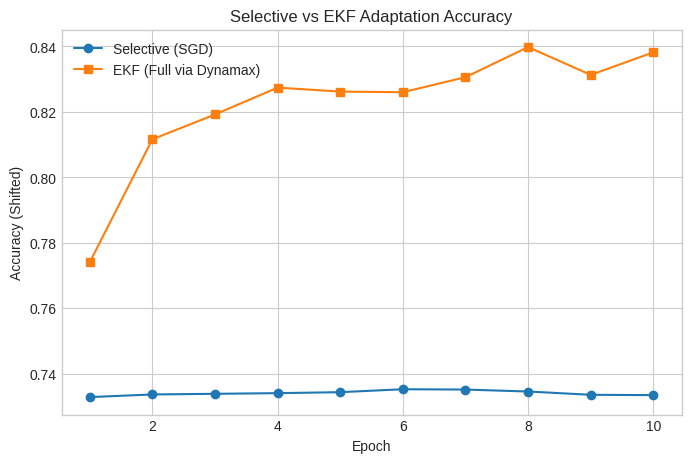

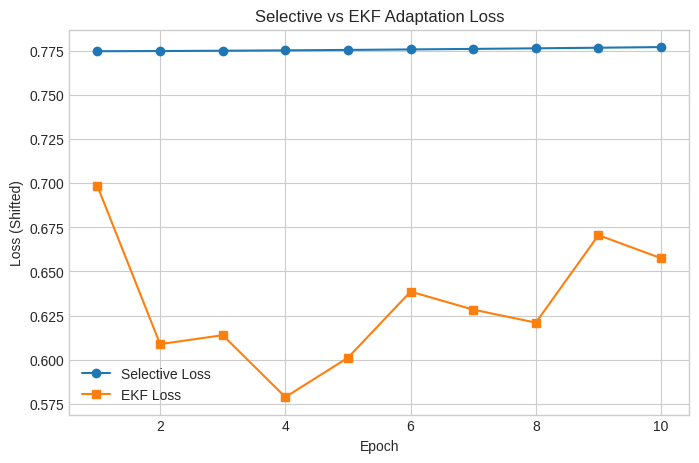


Δ Params Selective → EKF: 118.619865


In [8]:
# =====================================
# 7. Visualizations
# =====================================
epochs_ = np.arange(1, num_adapt_epochs + 1)
plt.style.use("seaborn-v0_8-whitegrid")
plt.figure(figsize=(8,5))
plt.plot(epochs_, sel_accs, "o-", label="Selective (SGD)")
plt.plot(epochs_, ekf_accs, "s-", label="EKF (Full via Dynamax)")
plt.xlabel("Epoch"); plt.ylabel("Accuracy (Shifted)")
plt.title("Selective vs EKF Adaptation Accuracy"); plt.legend(); plt.show()

plt.figure(figsize=(8,5))
plt.plot(epochs_, sel_losses, "o-", label="Selective Loss")
plt.plot(epochs_, ekf_losses, "s-", label="EKF Loss")
plt.xlabel("Epoch"); plt.ylabel("Loss (Shifted)")
plt.title("Selective vs EKF Adaptation Loss"); plt.legend(); plt.show()

# Parameter change magnitude
def l2_diff(m1, m2):
    def flat_params(m): return jax.tree_util.tree_flatten(nnx.state(m))[0]
    p1, p2 = flat_params(m1), flat_params(m2)
    return float(sum(jnp.linalg.norm(a-b) for a,b in zip(p1,p2)))
print(f"\nΔ Params Selective → EKF: {l2_diff(baseline_model, ekf_model):.6f}")


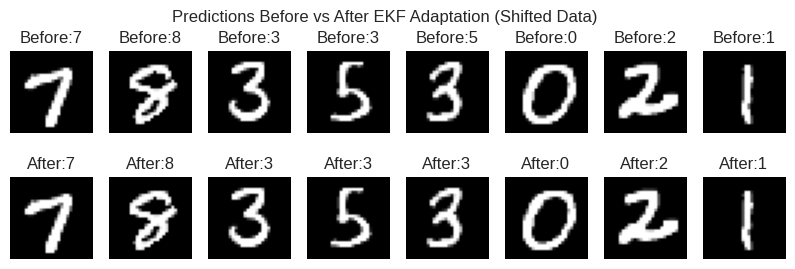

In [9]:

# =====================================
# 8. Before / After Prediction Visualization
# =====================================
def show_predictions(model_before, model_after, X, y, title):
    idx = np.random.choice(len(X), 8, replace=False)
    Xs, ys = X[idx], y[idx]
    h0 = jnp.zeros((Xs.shape[0], model_before.hidden_size))
    pred_before = jnp.argmax(model_before(Xs, h0), axis=-1)
    pred_after  = jnp.argmax(model_after(Xs, h0), axis=-1)
    fig, axes = plt.subplots(2, 8, figsize=(10,3))
    for i in range(8):
        axes[0,i].imshow(Xs[i], cmap="gray"); axes[0,i].set_title(f"Before:{pred_before[i]}")
        axes[1,i].imshow(Xs[i], cmap="gray"); axes[1,i].set_title(f"After:{pred_after[i]}")
        axes[0,i].axis("off"); axes[1,i].axis("off")
    plt.suptitle(title); plt.show()

show_predictions(baseline_model, ekf_model, X_test_shifted, y_test_shifted,
                 "Predictions Before vs After EKF Adaptation (Shifted Data)")

In [11]:
# =====================================
# 9. Comprehensive Experiment Summary
# =====================================
import pandas as pd

print("\n" + "="*70)
print("COMPREHENSIVE SUMMARY")
print("="*70)

# Baseline metrics
baseline_orig_acc = test_accs[-1] if 'test_accs' in locals() else float('nan')
baseline_shift_acc = float(a_shift)

# Selective adaptation metrics
sel_final_acc = sel_accs[-1] if len(sel_accs) > 0 else float('nan')
sel_final_loss = sel_losses[-1] if len(sel_losses) > 0 else float('nan')

# EKF metrics
ekf_final_acc = ekf_accs[-1] if len(ekf_accs) > 0 else float('nan')
ekf_final_loss = ekf_losses[-1] if len(ekf_losses) > 0 else float('nan')

# Compute accuracy improvements
sel_improvement = sel_final_acc - baseline_shift_acc
ekf_improvement = ekf_final_acc - baseline_shift_acc

# Parameter statistics
num_params = fc.kernel.value.size + fc.bias.value.size
l2_sel = l2_diff(baseline_model, selective_model) if 'selective_model' in locals() else float('nan')
l2_ekf = l2_diff(baseline_model, ekf_model)

# Memory estimates
mem_ekf = num_params**2     # full covariance
mem_sel = 0                 # none

# Construct summary table
summary = pd.DataFrame({
    "Metric": [
        "Accuracy (original data)",
        "Accuracy (shifted - before)",
        "Accuracy (shifted - after)",
        "Accuracy improvement",
        "Final loss",
        "Trainable parameters",
        "Memory overhead (elements)",
        "Parameter L2 change"
    ],
    "Baseline": [
        baseline_orig_acc,
        baseline_shift_acc,
        "-",
        "-",
        "-",
        num_params,
        "-",
        "-"
    ],
    "Selective (Adam)": [
        "-",
        baseline_shift_acc,
        sel_final_acc,
        sel_improvement,
        sel_final_loss,
        num_params,
        mem_sel,
        l2_sel
    ],
    "EKF (Dynamax)": [
        "-",
        baseline_shift_acc,
        ekf_final_acc,
        ekf_improvement,
        ekf_final_loss,
        num_params,
        mem_ekf,
        l2_ekf
    ]
})

print(summary.to_string(index=False, float_format=lambda x: f"{x:0.4f}"))

print("\n" + "="*70 + "\n")



COMPREHENSIVE SUMMARY
                     Metric Baseline Selective (Adam) EKF (Dynamax)
   Accuracy (original data)   0.7335                -             -
Accuracy (shifted - before)   0.7328           0.7328        0.7328
 Accuracy (shifted - after)        -           0.7334        0.8382
       Accuracy improvement        -           0.0006        0.1054
                 Final loss        -           0.7772        0.6575
       Trainable parameters     1290             1290          1290
 Memory overhead (elements)        -                0       1664100
        Parameter L2 change        -           0.3733      118.6199


